# Предварительный Exploratory Data Analysis
### Интервью Центра молодежных исследований, полученных для дальнейшего обучения модели по проекту tag-matic

**Данный анализ предполагает предварительное знакомство с данными** и включает следующие этапы:

- **Оформление датасета** из полученных документов
- **Анализ объема корпуса**
- **Первичный анализ метаданных**: демографические характеристики
- **Первичный тематический анализ**: ключевые слова и биграммы


In [18]:
!pip install python_docx
!pip install gensim
from docx import Document
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import gensim
import gensim.corpora as corpora
from gensim.corpora import Dictionary
import pickle
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.5 MB/s eta 0:00:00


## Оформление датасета
- первичный анализ полученных данных

In [2]:
# Извлечение темы блока интервью
def extract_theme(doc):
    """Извлекает тему блока интервью из первых параграфов"""
    for para in doc.paragraphs[:5]:
        text = para.text.strip()
        if 'Тема:' in text:
            match = re.search(r'Тема:\s*(.+)', text)
            return match.group(1).strip() if match else text
    return "Не определена"

def process_single_doc(doc_path, global_id_start=1):
    doc = Document(doc_path)
    theme = extract_theme(doc)
    print(f"{os.path.basename(doc_path)} → Тема: '{theme[:80]}...'")

# Извлечение данных из таблиц
    tables_data = []
    for table in doc.tables:
        metadata = {}
        for row in table.rows[1:]:
            cells = [cell.text.strip() for cell in row.cells]
            if len(cells) >= 2:
                key = cells[0].replace('/', '').replace('?', '').strip()
                value = cells[1].strip()
                metadata[key] = value
        tables_data.append(metadata)

# Извлечение транскриптов интервью
    full_text = []
    for para in doc.paragraphs:
        if para.text.strip():
            full_text.append(para.text.strip())
    full_text = '\n'.join(full_text)

    # разбивка по интервью
    interviews = re.split(r'(?=Интервью №\s*\d+[\.\]\)\s]?)', full_text)[1:]

# Соединение таблицы и транскрипта
    data = []
    for i in range(min(len(tables_data), len(interviews))):
        metadata = tables_data[i]
        interview_block = interviews[i]

        metadata_end = interview_block.find('Интервьюер:')
        if metadata_end == -1:
            metadata_end = interview_block.find('Информант:')

        transcript_text = interview_block[metadata_end:].strip() if metadata_end != -1 else interview_block

        record = {
            'global_interview_id': global_id_start + i,
            'doc_filename': os.path.basename(doc_path),
            'theme': theme,
            'local_interview_id': i + 1,
            'date': metadata.get('Дата интервью', metadata.get('Дата проведения интервью', 'N/A')),
            'duration': metadata.get('Длительность, мин', metadata.get('Длительность интервью', 'N/A')),
            'gender': metadata.get('Пол', metadata.get('Пол информанта', 'N/A')),
            'age': metadata.get('Возраст', metadata.get('Возраст информанта', 'N/A')),
            'location': metadata.get('Город', 'N/A'),
            'occupation': metadata.get('Занятость', 'N/A'),
            'education': metadata.get('Образование', 'N/A'),
            'marital_status': metadata.get('Брачный статус, дети', metadata.get('Брачный статус дети', 'N/A')),
            'transcript': transcript_text
        }
        data.append(record)

    return data, len(data)

doc_files = [
    'пул интервью 1.docx',
    'пул интервью 2.docx',
    'пул интервью 3.docx',
    'пул интервью 4.docx'
]

all_data = []
global_id = 1

for doc_file in doc_files:
    if os.path.exists(doc_file):
        data, count = process_single_doc(doc_file, global_id)
        all_data.extend(data)
        print(f"   {count} интервью добавлено (глобальные ID {global_id}-{global_id+count-1})")
        global_id += count
    else:
        print(f"Не найден: {doc_file}")

df = pd.DataFrame(all_data)
print(f"\n\n Итог: {len(df)} интервью из {len(doc_files)} документов")

df['age_num'] = pd.to_numeric(df['age'], errors='coerce')
print("\nСтатистика")
print(f"\nВсего интервью: {len(df)}")
print(f"Средний возраст: {df['age_num'].mean():.1f}")
print(f"Возрастной диапазон: {df['age_num'].min()}-{df['age_num'].max()}")
print("\nРаспределение по полу:")
print(df['gender'].value_counts())

df.to_csv('all_interviews_unified.csv', index=False)

пул интервью 1.docx → Тема: 'Поколенческая идентичность, жизненные выборы и устойчивость Российской молодежи...'
   29 интервью добавлено (глобальные ID 1-29)
пул интервью 2.docx → Тема: 'Поколение Z в поисках баланса: условия труда, режимы работы и жизненные ценности...'
   61 интервью добавлено (глобальные ID 30-90)
пул интервью 3.docx → Тема: 'Созидательный потенциал самостоятельного проактивного действия населения России...'
   30 интервью добавлено (глобальные ID 91-120)
пул интервью 4.docx → Тема: 'Многообразие форм, эффектов и барьеров интеграции современной российской молодеж...'
   29 интервью добавлено (глобальные ID 121-149)


 Итог: 149 интервью из 4 документов

Статистика

Всего интервью: 149
Средний возраст: 26.0
Возрастной диапазон: 18.0-61.0

Распределение по полу:
gender
Ж          82
М          66
Ж, М, М     1
Name: count, dtype: int64


In [16]:
df.head()

,global_interview_id,doc_filename,theme,local_interview_id,date,duration,gender,age,location,occupation,education,marital_status,transcript,age_num,transcript_length,word_count,symbols_count
0,1,пул интервью 1.docx,"Поколенческая идентичность, жизненные выборы и...",1,17.05.23,1 ч. 35 мин.,Ж,25,N/A,Фотограф-фрилансер,Студентка бакалавриата (в академ. отпуске),"Не замужем, детей нет","Интервьюер: Так, все, все записи начались. Сна...",25.0,92579,15492,92579
1,2,пул интервью 1.docx,"Поколенческая идентичность, жизненные выборы и...",2,21.06.23,1 ч. 24 мин.,Ж,25,N/A,Занимается UX-дизайном как фрилансер,"ВО, магистратура",Замужем,"Интервьюер: Смотри, вначале расскажи, пожалуйс...",25.0,63210,10251,63210
2,3,пул интервью 1.docx,"Поколенческая идентичность, жизненные выборы и...",3,05.05.23,1 ч. 11 мин.,М,27,N/A,"Фрилансер (журналист, иллюстратор)","ВО, магистратура","Не женат, детей нет","Интервьюер: Так, тогда начинаем. Расскажи спер...",27.0,50886,8155,50886
3,4,пул интервью 1.docx,"Поколенческая идентичность, жизненные выборы и...",4,09.05.23,2 ч. 6 мин.,М,35,N/A,Предприниматель,"ВО, бакалавриат","Женат, детей нет","Интервьюер: Тогда, наверное, начнем. Сперва мо...",35.0,56119,9023,56119
4,5,пул интервью 1.docx,"Поколенческая идентичность, жизненные выборы и...",5,06.04.23,1 ч. 5 мин.,М,26,N/A,"Владелец секондхенда, организатор коммуны",Среднее (отчислился из университета),"Не женат, детей нет",Интервьюер: Для начала расскажи о себе. Скольк...,26.0,50196,7749,50196


## Анализ объема корпуса текстов

Статистика:
                     symbols_count  word_count
doc_filename                                  
пул интервью 1.docx        2559131      419532
пул интервью 2.docx        4705781      753215
пул интервью 3.docx        1943796      307233
пул интервью 4.docx        2542328      409519

Общее число слов в корпусе текстов = 1889499 
Общее число символов в корпусе текстов = 11751036 



/tmp/ipykernel_164/797851500.py:9: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  print(df.groupby('doc_filename')[['symbols_count', 'word_count']].agg(sum))
/tmp/ipykernel_164/797851500.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1600x800 with 0 Axes>

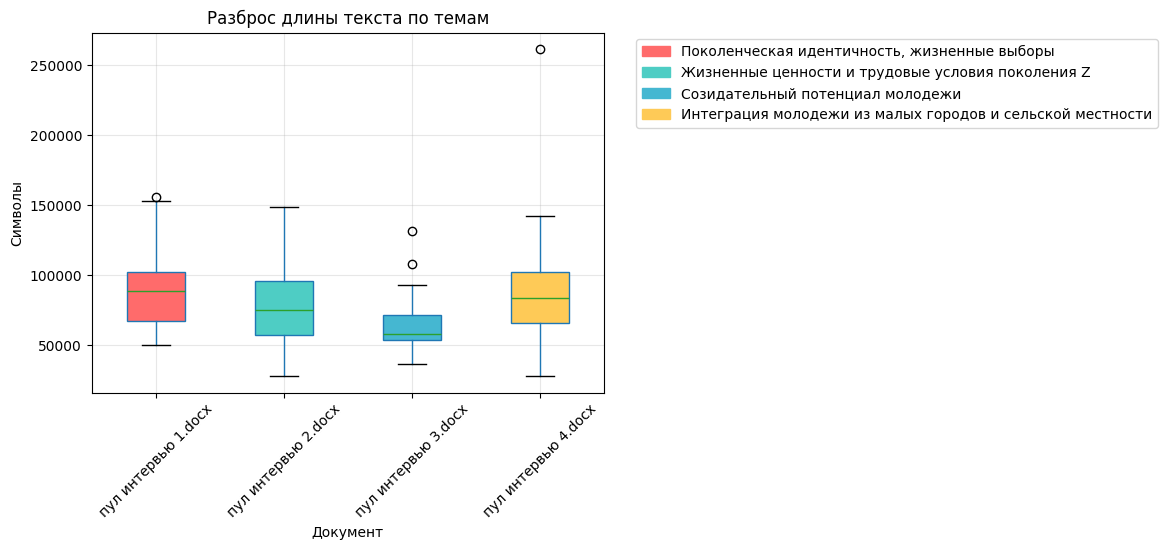

In [15]:
df['symbols_count'] = df['transcript'].str.len()
df['word_count'] = df['transcript'].str.split().str.len()

print("Статистика:")
print(df.groupby('doc_filename')[['symbols_count', 'word_count']].agg(sum))
print(f"\nОбщее число слов в корпусе текстов = {df['word_count'].sum()} \nОбщее число символов в корпусе текстов = {df['symbols_count'].sum()} \n")


file_theme_colors = {
    'пул интервью 1.docx': ('Поколенческая идентичность, жизненные выборы', '#FF6B6B'),
    'пул интервью 2.docx': ('Жизненные ценности и трудовые условия поколения Z', '#4ECDC4'),
    'пул интервью 3.docx': ('Созидательный потенциал молодежи', '#45B7D1'),
    'пул интервью 4.docx': ('Интеграция молодежи из малых городов и сельской местности', '#FECA57')
}

plt.figure(figsize=(16, 8))

bp = df.boxplot(column='symbols_count', by='doc_filename', patch_artist=True)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FECA57']

for i in range(4):
    start = i
    end = i + 1
    for patch in bp.patches[start:end]:
        patch.set_facecolor(colors[i])

plt.title('Разброс длины текста по темам')
plt.suptitle('')
plt.ylabel('Символы')
plt.xlabel('Документ')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

legend_elements = [mpatches.Patch(color=color, label=theme)
                  for file, (theme, color) in file_theme_colors.items()]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Общий объём корпуса составляет 11,75 млн символов и 1,89 млн слов (149 интервью из 4 тематических блоков).

Основные характеристики:

- пул интервью №2 доминирует
- пулы №1,4 сбалансированы
- пул №3 наименее представлен

Корпус объёмом 1,89 млн токенов соответствует требованиям для обучения моделей кодировок по проекту tag-matic.
Корпус обладает достаточной репрезентативностью и объёмом для последующих этапов исследования.

## Подготовка корпуса текстов
### Первичный тематический анализ

Лемматизация

In [20]:
STOPWORDS = stopwords.words('russian') + ['и', 'в', 'не', 'на', 'я', 'с', 'что', 'он', 'по', 'как', 'а', 'у', 'за', 'бы', 'но',
    'да', 'нет', 'ну', 'так', 'вот', 'это', 'тот', 'тут', 'там', 'все', 'очень',
    'интервьюер', 'информант', 'сказать', 'рассказать', 'подумать', 'смотреть',
    'думаю', 'считаю', 'кажется', 'начало', 'конец', 'может', 'быть', 'кто', 'где']

def simple_lemmatize(text):
    words = re.findall(r'\b\w+\b', text.lower())
    return [w for w in words if len(w) > 2 and w not in STOPWORDS]

df['transcript_lemmatized'] = df['transcript'].apply(simple_lemmatize)
df['transcript_lemmatized_str'] = df['transcript_lemmatized'].apply(' '.join)
print("Тексты после лемматизации: \n", df['transcript_lemmatized_str'].head(2))


Тексты после лемматизации: 
 0    записи начались сначала попрошу какую основную...
1    смотри вначале расскажи пожалуйста немного ско...
Name: transcript_lemmatized_str, dtype: object


In [21]:
texts_clean = []
for text in tqdm(df['transcript_lemmatized']):
    clean_text = [word for word in text if len(word) > 3]
    if len(clean_text) > 5:
        texts_clean.append(clean_text)

print(f"После фильтрации: {len(texts_clean)} текстов (было {len(df)})")

100%|██████████| 149/149 [00:00<00:00, 1408.06it/s]

После фильтрации: 149 текстов (было 149)


In [22]:
texts = texts_clean
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

dictionary.filter_extremes(no_below=3, no_above=0.6)
corpus = [dictionary.doc2bow(text) for text in texts]

print(f"Dictionary: {len(dictionary)} слов")
print(f"Corpus: {len(corpus)} документов")

pickle.dump(corpus, open('corpus_clean.pkl', 'wb'))
pickle.dump(dictionary, open('dictionary_clean.pkl', 'wb'))



Dictionary: 21076 слов
Corpus: 149 документов


После фильтрации слишком редких и слишком частых слов словарь составляет 21K уникальных слов, представляя оптимальный размер для качественного моделирования

## LDA модель
- общее представление о текстах с помощью простого анализа тем





ТЕМЫ
Тема 1: 0.002*"окей" + 0.002*"могла" + 0.002*"думала" + 0.002*"говорила" + 0.002*"расскажи" + 0.001*"училась"
Тема 2: 0.005*"понял" + 0.002*"сотрудников" + 0.002*"грубо" + 0.001*"пошел" + 0.001*"смотри" + 0.001*"смех"
Тема 3: 0.006*"проекта" + 0.005*"смех" + 0.003*"проекты" + 0.002*"инициатива" + 0.002*"проекте" + 0.002*"смешок"
Тема 4: 0.003*"сотрудников" + 0.003*"молодежь" + 0.002*"молодежи" + 0.002*"проекта" + 0.002*"смеется" + 0.002*"готовы"
Тема 5: 0.003*"можете" + 0.002*"понял" + 0.002*"смех" + 0.002*"грубо" + 0.002*"окей" + 0.002*"этап"


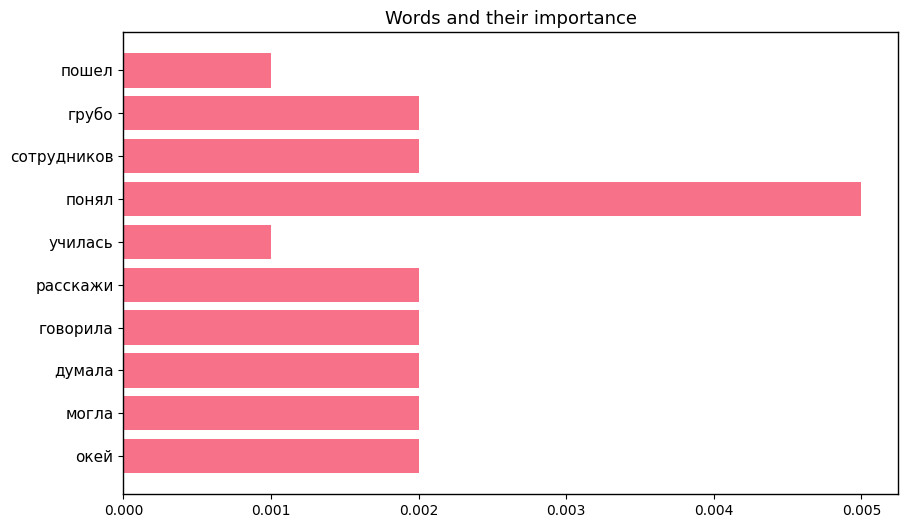

In [81]:
lda_model = gensim.models.LdaModel(
    corpus=corpus, id2word=dictionary,
    num_topics=5,
    passes=10,
    iterations=100,
    alpha='auto',
    eta='auto'
)

topics = lda_model.print_topics(num_words=6)
print("ТЕМЫ")
for i, topic in topics:
    print(f"Тема {i+1}: {topic}")


fig, ax = plt.subplots(figsize=(10, 6))
all_words, all_scores = [], []
for i, topic in topics:
    words_scores = topic.split(' + ')
    for ws in words_scores:
        if '*' in ws:
            score_str, word = ws.split('*', 1)
            word = word.strip('"\' ')
            try:
                all_scores.append(float(score_str))
                all_words.append(word)
            except:
                pass

ax.barh(range(len(all_words[:10])), all_scores[:10])
ax.set_yticks(range(len(all_words[:10])))
ax.set_yticklabels(all_words[:10])
ax.set_title('Words and their importance')
plt.show()

Модель частично успешно выделяет тематические блоки, но требует доработки и более качественной предобработки текстов. Однако, результаты позволяют заметить ключевые фокусы текстов:
- проектная активность (инициативы, проекты, училась)
- трудовые отношения (сотрудники)
- молодёжная повестка (молодёжь, вовлечение)

## TF-IDF модель
- общее описание через частые биграммы

In [87]:
vectorizer = TfidfVectorizer(
    max_df=0.5,
    min_df=3,
    ngram_range=(2, 3),
    stop_words=STOPWORDS
)

tfidf_matrix = vectorizer.fit_transform(df['transcript_lemmatized_str'])
feature_names = vectorizer.get_feature_names_out()

sums = tfidf_matrix.sum(axis=0).A1
top_indices = sums.argsort()[-20:][::-1]

print("Основные обсуждения (биграммы):\n")
for i, idx in enumerate(top_indices):
    print(f"{i+1}. '{feature_names[idx]}' (TF-IDF: {sums[idx]:.3f})")

Основные обсуждения (биграммы):

1. 'название города' (TF-IDF: 3.574)
2. 'название проекта' (TF-IDF: 3.168)
3. 'молодых сотрудников' (TF-IDF: 2.142)
4. 'честно говоря' (TF-IDF: 2.075)
5. 'ваше поколение' (TF-IDF: 2.012)
6. 'условно говоря' (TF-IDF: 1.988)
7. 'наше поколение' (TF-IDF: 1.846)
8. 'твоего поколения' (TF-IDF: 1.836)
9. 'нравится нравится' (TF-IDF: 1.736)
10. 'плюс минус' (TF-IDF: 1.723)
11. 'понятное дело' (TF-IDF: 1.719)
12. 'вообще какие' (TF-IDF: 1.659)
13. 'твое поколение' (TF-IDF: 1.644)
14. 'молодой человек' (TF-IDF: 1.587)
15. 'вуз спб' (TF-IDF: 1.566)
16. 'вообще принципе' (TF-IDF: 1.517)
17. 'рабочий день' (TF-IDF: 1.488)
18. 'знаю просто' (TF-IDF: 1.469)
19. 'расскажи пожалуйста' (TF-IDF: 1.454)
20. 'тебе нужно' (TF-IDF: 1.448)


TF-IDF подтверждает тематику LDA, подробнее расскрывая темы  обсуждений через наиболее употребляемые биграммы.

**1. Проектная и учебная активность**  
название проекта, название города, вуз спб

**2. Поколенческая идентичность**
ваше поколение, наше поколение, твое поколение, твоего поколения

**3. Трудовые отношения**
молодых сотрудников, рабочий день

**4. Разговорные маркеры**
честно говоря, условно говоря, понятное дело, плюс минус, знаю просто


### Общий вывод

Проведённый предварительный анализ корпуса из 149 интервью (1,89 млн слов, 11,75 млн символов) позволил сформировать системное представление о структуре, объёмах и тематической специфике данных.

Основные характеристики:

- достаточный объём для обучения моделей
- доминирование тем проектной активности, поколенческой идентичности и трудовых отношений
- наличие речевых артефактов, требующих предобработки

Практическая значимость анализа заключается в предварительном ознакомлении с корпусом, обеспечивая выявления ключевых тем для целевого моделирования и определения необходимых шагов предобработки.


Корпус обладает высокой репрезентативностью и готовностью к машинному обучению в рамках проекта tag-matic.